# Clima

## Estadisticas climaticas 1991 - 2020
"Se deja constancia que la información vertida en el presente informe puede sufrir variaciones debido a los procesos de consistencia y depuración a los que es sometida la misma
S/D: Sin Dato
Las estadísticas de las estaciones que poseen un asterisco (*) en su nombre, fueron confeccionadas con un período algo menor que 1991-2020  "													
												

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
temp = pd.read_csv("..//data//raw//estadisticas_normales_9120//Estadísticas-normales-Datos-abiertos-1991-2020.csv",
                           sep=";")
temp

,Estación,Valor Medio de,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
0,LA QUIACA OBSERVATORIO,Temperatura (°C),"13,2",13,"12,8","11,3","7,3","4,8","4,5",7,10,"12,4","13,4","13,9"
1,LA QUIACA OBSERVATORIO,Temperatura máxima (°C),"20,6","20,4","20,6","20,3","17,8","16,3","16,1",18,20,"21,7","22,5","22,2"
2,LA QUIACA OBSERVATORIO,Temperatura mínima (°C),"7,7","7,6","6,6","3,1","-2,5","-5,7","-6,2",-4,"-0,4","3,3","5,5","7,3"
3,LA QUIACA OBSERVATORIO,Humedad relativa (%),"62,6","63,2","60,3",46,"32,6","27,4","25,7","26,7","32,1","42,4","48,6","55,8"
4,LA QUIACA OBSERVATORIO,Velocidad del Viento (km/h) (2011-2020),"6,5","6,8","6,7","5,5","4,8","5,5","5,9","6,7","7,9","7,9","7,7","7,1"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,BASE SAN MARTÍN,Humedad relativa (%),"71,2","74,6",S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,"73,2"
780,BASE SAN MARTÍN,Velocidad del Viento (km/h) (2011-2020),S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D
781,BASE SAN MARTÍN,Nubosidad total (octavos),"6,3","6,5","6,4","6,1","5,9","5,2","5,4","5,8","6,2","6,5","6,3","6,2"
782,BASE SAN MARTÍN,Precipitación (mm),S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D,S/D


In [3]:
temp[temp["Valor Medio de"] == "Temperatura máxima (°C)"]

,Estación,Valor Medio de,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
1,LA QUIACA OBSERVATORIO,Temperatura máxima (°C),"20,6","20,4","20,6","20,3","17,8","16,3","16,1",18,20,"21,7","22,5","22,2"
9,ORÁN AERO*,Temperatura máxima (°C),"32,8","31,4","29,4","26,5","23,4","21,6","22,4","26,2","29,4","31,8","32,4","33,2"
17,TARTAGAL AERO,Temperatura máxima (°C),"32,3",31,29,"26,1",23,"21,5","22,1",26,"28,9","31,4","31,9","32,5"
25,JUJUY AERO,Temperatura máxima (°C),"30,3","28,8","27,1","24,3","21,3","19,9","20,1","23,6","26,4",29,30,"30,7"
33,JUJUY U N,Temperatura máxima (°C),"27,3","26,2","24,8","22,4","19,6","18,6","18,6","21,7",24,"26,4","27,1","27,7"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,BASE ORCADAS,Temperatura máxima (°C),"3,6","3,4","2,4","0,4",-2,"-3,9","-5,3","-4,1",-2,"0,6","2,5",3
753,BASE BELGRANO II,Temperatura máxima (°C),"0,7","-3,5","-9,1","-13,2","-14,1","-15,7","-17,5","-17,1","-14,9","-10,2","-3,2","0,8"
761,BASE CARLINI (EX JÚBANY),Temperatura máxima (°C),"4,3","3,9","2,9","0,9","-0,4","-2,5",-3,"-2,6","-1,2","0,2","1,7","3,2"
769,BASE MARAMBIO,Temperatura máxima (°C),"1,7",1,"-2,1","-6,1","-7,4","-10,7","-10,3","-9,3","-6,1","-3,6","-0,4","1,3"


In [4]:
temp.columns

Index(['Estación', 'Valor Medio de', 'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
       'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'],
      dtype='object')

In [5]:
temp.value_counts('Valor Medio de')

Valor Medio de
Frecuencia de días con Precipitación superior a 1.0 mm    98
Humedad relativa (%)                                      98
Nubosidad total (octavos)                                 98
Precipitación (mm)                                        98
Temperatura (°C)                                          98
Temperatura máxima (°C)                                   98
Temperatura mínima (°C)                                   98
Velocidad del Viento (km/h) (2011-2020)                   98
Name: count, dtype: int64

### Precipitación (mm)

In [6]:
precipitacion = temp[temp["Valor Medio de"] == "Precipitación (mm)"]

#Elimino columna y coloco un nuevo indice
del precipitacion["Valor Medio de"]
precipitacion = precipitacion.set_index("Estación")

# Reemplazar las S/D por cero.
precipitacion[precipitacion.isin(["S/D"])] = 0

# Reemplazar las comas por puntos.
for i in precipitacion.columns:
    precipitacion[i] = precipitacion[i].str.replace(',','.').astype(float)
    
precipitacion

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
Estación,,,,,,,,,,,,
LA QUIACA OBSERVATORIO,101.9,67.9,48.1,6.8,1.1,0.0,0.0,1.2,3.9,14.4,22.2,63.2
ORÁN AERO*,198.4,185.9,157.8,59.5,22.6,7.1,3.0,3.5,16.3,58.9,97.3,157.3
TARTAGAL AERO,193.2,197.8,164.5,59.3,24.4,8.7,4.0,3.8,17.9,46.3,112.2,165.0
JUJUY AERO,147.6,154.0,131.8,51.7,13.6,4.3,2.8,2.1,5.1,28.8,56.1,122.5
JUJUY U N,191.5,188.0,166.5,62.0,20.9,9.5,7.1,5.9,9.4,40.8,97.5,152.1
...,...,...,...,...,...,...,...,...,...,...,...,...
BASE ORCADAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BASE BELGRANO II,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BASE CARLINI (EX JÚBANY),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

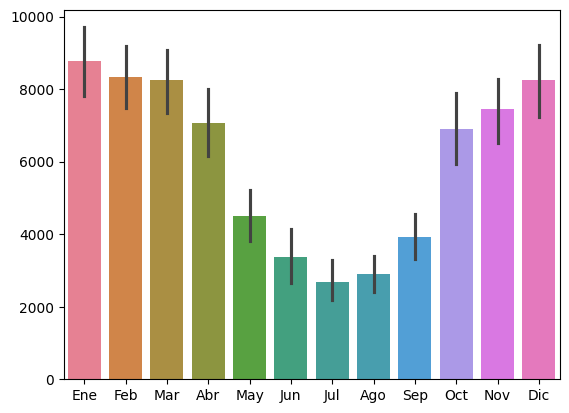

In [7]:
# sns.set_theme(style="ticks")
sns.barplot(precipitacion, estimator="sum")

### Temperatura

In [8]:
temperatura = temp[temp["Valor Medio de"] == "Temperatura (°C)"]
del temperatura["Valor Medio de"]
temperatura =temperatura.set_index("Estación")

# Reemplazar las S/D por cero.
temperatura[temperatura.isin(["S/D"])] = 0
    
    
# Reemplazar las comas por puntos.
for i in temperatura.columns:
    temperatura[i] = temperatura[i].str.replace(",",".").astype(float)
    

    
temperatura

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
Estación,,,,,,,,,,,,
LA QUIACA OBSERVATORIO,13.2,13.0,12.8,11.3,7.3,4.8,4.5,7.0,10.0,12.4,13.4,13.9
ORÁN AERO*,26.4,25.4,23.9,21.3,18.1,15.6,14.9,17.6,21.0,24.5,25.5,26.4
TARTAGAL AERO,26.0,24.9,23.5,20.9,17.7,15.4,14.8,17.9,21.1,24.4,25.2,26.0
JUJUY AERO,23.8,22.7,21.3,18.5,15.1,12.5,11.9,15.1,18.4,21.9,23.1,24.0
JUJUY U N,21.1,20.2,19.1,16.6,13.4,11.1,10.2,13.0,15.7,19.0,20.2,21.3
...,...,...,...,...,...,...,...,...,...,...,...,...
BASE ORCADAS,1.3,1.4,0.3,-1.8,-5.0,-7.5,-9.4,-8.1,-5.6,-2.7,-0.6,0.5
BASE BELGRANO II,-2.6,-7.1,-12.3,-16.4,-17.5,-18.9,-20.9,-20.7,-18.4,-14.1,-7.0,-2.7
BASE CARLINI (EX JÚBANY),2.2,2.0,0.9,-1.2,-2.8,-5.2,-5.8,-5.3,-3.7,-1.9,-0.2,1.2


<Axes: >

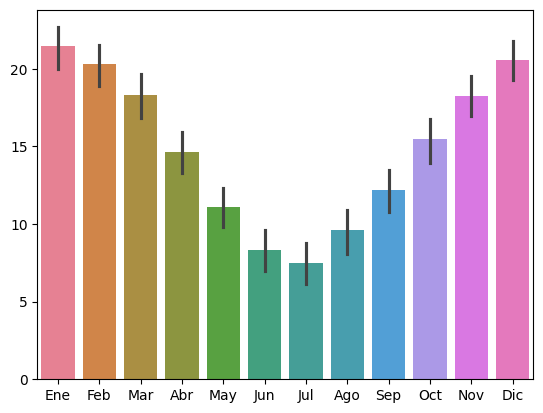

In [9]:
sns.barplot(temperatura)

### Temperatura máxima

In [10]:
temperatura_max = temp[temp["Valor Medio de"] == "Temperatura máxima (°C)"]
del temperatura_max["Valor Medio de"]
temperatura_max =temperatura_max.set_index("Estación")

# Reemplazar las S/D por cero.
temperatura_max[temperatura_max.isin(["S/D"])] = 0
    
    
# Reemplazar las comas por puntos.
for i in temperatura_max.columns:
    temperatura_max[i] = temperatura_max[i].str.replace(",",".").astype(float)
    

    
temperatura_max


,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
Estación,,,,,,,,,,,,
LA QUIACA OBSERVATORIO,20.6,20.4,20.6,20.3,17.8,16.3,16.1,18.0,20.0,21.7,22.5,22.2
ORÁN AERO*,32.8,31.4,29.4,26.5,23.4,21.6,22.4,26.2,29.4,31.8,32.4,33.2
TARTAGAL AERO,32.3,31.0,29.0,26.1,23.0,21.5,22.1,26.0,28.9,31.4,31.9,32.5
JUJUY AERO,30.3,28.8,27.1,24.3,21.3,19.9,20.1,23.6,26.4,29.0,30.0,30.7
JUJUY U N,27.3,26.2,24.8,22.4,19.6,18.6,18.6,21.7,24.0,26.4,27.1,27.7
...,...,...,...,...,...,...,...,...,...,...,...,...
BASE ORCADAS,3.6,3.4,2.4,0.4,-2.0,-3.9,-5.3,-4.1,-2.0,0.6,2.5,3.0
BASE BELGRANO II,0.7,-3.5,-9.1,-13.2,-14.1,-15.7,-17.5,-17.1,-14.9,-10.2,-3.2,0.8
BASE CARLINI (EX JÚBANY),4.3,3.9,2.9,0.9,-0.4,-2.5,-3.0,-2.6,-1.2,0.2,1.7,3.2


<Axes: >

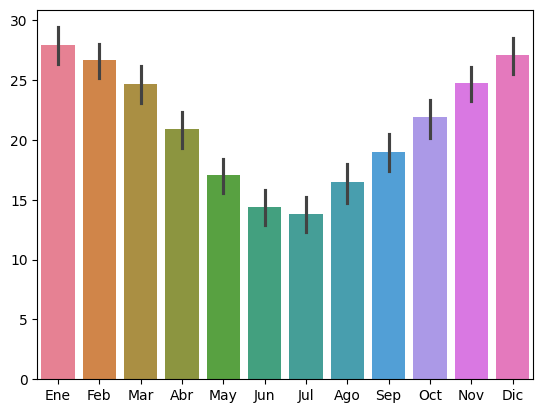

In [11]:
sns.barplot(temperatura_max)

### Temperatura mínima

In [12]:
temperatura_min = temp[temp["Valor Medio de"] == "Temperatura mínima (°C)"]
del temperatura_min["Valor Medio de"]
temperatura_min =temperatura_min.set_index("Estación")

# Reemplazar las S/D por cero.
temperatura_min[temperatura_min.isin(["S/D"])] = 0
    
    
# Reemplazar las comas por puntos.
for i in temperatura_min.columns:
    temperatura_min[i] = temperatura_min[i].str.replace(",",".").astype(float)
    

    
temperatura_min

,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
Estación,,,,,,,,,,,,
LA QUIACA OBSERVATORIO,7.7,7.6,6.6,3.1,-2.5,-5.7,-6.2,-4.0,-0.4,3.3,5.5,7.3
ORÁN AERO*,21.6,21.2,20.3,17.9,14.5,11.3,9.6,11.1,14.2,18.4,19.7,21.2
TARTAGAL AERO,20.8,20.3,19.5,17.1,13.6,11.1,9.3,10.9,14.1,18.0,19.1,20.4
JUJUY AERO,18.5,17.9,17.0,14.1,10.4,7.3,6.0,8.2,11.0,15.1,16.7,18.1
JUJUY U N,16.7,16.2,15.5,12.7,9.1,5.9,4.5,6.4,9.1,12.9,14.6,16.2
...,...,...,...,...,...,...,...,...,...,...,...,...
BASE ORCADAS,-0.7,-0.4,-1.6,-4.1,-8.1,-11.3,-14.1,-12.4,-9.8,-6.0,-3.2,-1.7
BASE BELGRANO II,-6.1,-11.1,-16.5,-20.5,-21.6,-23.0,-25.0,-24.9,-22.8,-18.8,-11.5,-6.8
BASE CARLINI (EX JÚBANY),0.4,0.2,-1.2,-3.4,-5.3,-8.1,-9.0,-8.3,-6.5,-4.2,-2.2,-0.6


<Axes: >

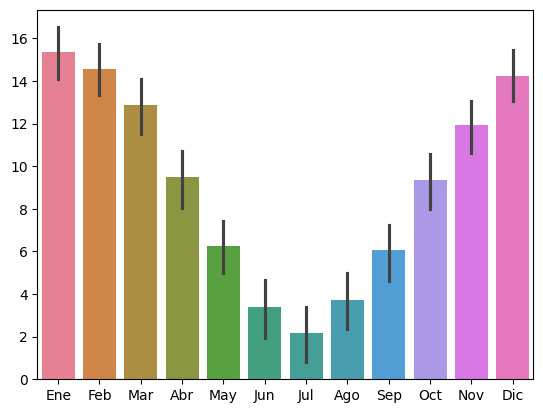

In [13]:
sns.barplot(temperatura_min)

### Olas de calor

In [14]:
ola_calor = pd.read_csv("..//data//raw//olas-de-calor.csv",
                           sep=";")
ola_calor
# temperatura_min = temp[temp["Valor Medio de"] == "Temperatura mínima (°C)"]
# del temperatura_min["Valor Medio de"]
# temperatura_min =temperatura_min.set_index("Estación")

# # Reemplazar las S/D por cero.
# temperatura_min[temperatura_min.isin(["S/D"])] = 0
    
    
# # Reemplazar las comas por puntos.
# for i in temperatura_min.columns:
#     temperatura_min[i] = temperatura_min[i].str.replace(",",".").astype(float)
    

    
# temperatura_min

,Duración (días),Fecha de inicio,Fecha de fin,Temperatura máxima absoluta,Temperatura mínima absoluta
0,9,22/12/2013,30/12/2013,39.0,27.2
1,8,31/12/2004,07/01/2005,38.0,26.7
2,8,23/02/2017,02/03/2017,35.2,25.3
3,7,01/01/1989,07/01/1989,36.5,26.0
4,7,28/02/2023,06/03/2023,38.0,25.5
...,...,...,...,...,...
66,3,19/02/2019,21/02/2019,36.6,26.6
67,3,24/01/2020,26/01/2020,36.7,23.8
68,3,06/02/2023,08/02/2023,35.3,25.8
69,3,06/02/2024,08/02/2024,35.0,25.1


In [15]:
ola_calor["Fecha de fin"] = pd.to_datetime(ola_calor["Fecha de fin"])
ola_calor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Duración (días)              71 non-null     int64         
 1   Fecha de inicio              71 non-null     object        
 2   Fecha de fin                 71 non-null     datetime64[ns]
 3   Temperatura máxima absoluta  71 non-null     float64       
 4   Temperatura mínima absoluta  71 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 2.9+ KB


C:\Users\mbustos_lightech\AppData\Local\Temp\ipykernel_39452\3853432799.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ola_calor["Fecha de fin"] = pd.to_datetime(ola_calor["Fecha de fin"])


In [16]:
ola_calor

,Duración (días),Fecha de inicio,Fecha de fin,Temperatura máxima absoluta,Temperatura mínima absoluta
0,9,22/12/2013,2013-12-30,39.0,27.2
1,8,31/12/2004,2005-01-07,38.0,26.7
2,8,23/02/2017,2017-03-02,35.2,25.3
3,7,01/01/1989,1989-01-07,36.5,26.0
4,7,28/02/2023,2023-03-06,38.0,25.5
...,...,...,...,...,...
66,3,19/02/2019,2019-02-21,36.6,26.6
67,3,24/01/2020,2020-01-26,36.7,23.8
68,3,06/02/2023,2023-02-08,35.3,25.8
69,3,06/02/2024,2024-02-08,35.0,25.1


In [17]:
ola_calor["año"] = ola_calor["Fecha de fin"].dt.year
ola_calor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Duración (días)              71 non-null     int64         
 1   Fecha de inicio              71 non-null     object        
 2   Fecha de fin                 71 non-null     datetime64[ns]
 3   Temperatura máxima absoluta  71 non-null     float64       
 4   Temperatura mínima absoluta  71 non-null     float64       
 5   año                          71 non-null     int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(1)
memory usage: 3.2+ KB


### El total de días considerados dentro de una ola de calor

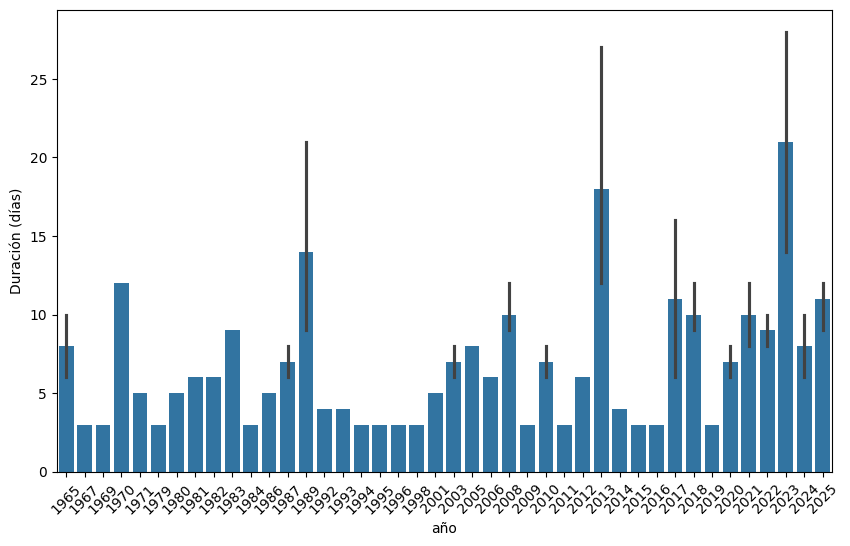

In [18]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
sns.barplot(data=ola_calor,x="año", y="Duración (días)", estimator="sum")
plt.xticks(rotation=45)
plt.show()

In [19]:
len(years)

NameError: name 'years' is not defined

In [ ]:
years = list(range(1961,2026,1))
datos_sample = {
    'Duración (días)':np.repeat(["0"],65), 
    'Fecha de inicio':np.repeat(["NaN"],65), 
    'Fecha de fin': np.repeat(["NaN"],65),
    'Temperatura máxima absoluta': np.repeat(["NaN"],65), 
    'Temperatura mínima absoluta': np.repeat(["NaN"],65), 
    'año':years}

# datos_sample

In [ ]:
df_datos_sample = pd.DataFrame(datos_sample)

In [ ]:
ola_calor_ext = pd.concat([ola_calor, df_datos_sample])

In [ ]:
ola_calor_ext["Duración (días)"] =  ola_calor_ext["Duración (días)"].astype(int)
ola_calor_ext["Fecha de fin"] =  pd.to_datetime(ola_calor_ext["Fecha de fin"])
ola_calor_ext["año"] =  ola_calor_ext["año"].astype(int)
ola_calor_ext.info()

<class 'pandas.core.frame.DataFrame'>
Index: 136 entries, 0 to 64
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Duración (días)              136 non-null    int32         
 1   Fecha de inicio              136 non-null    object        
 2   Fecha de fin                 71 non-null     datetime64[ns]
 3   Temperatura máxima absoluta  136 non-null    object        
 4   Temperatura mínima absoluta  136 non-null    object        
 5   año                          136 non-null    int32         
dtypes: datetime64[ns](1), int32(2), object(3)
memory usage: 6.4+ KB


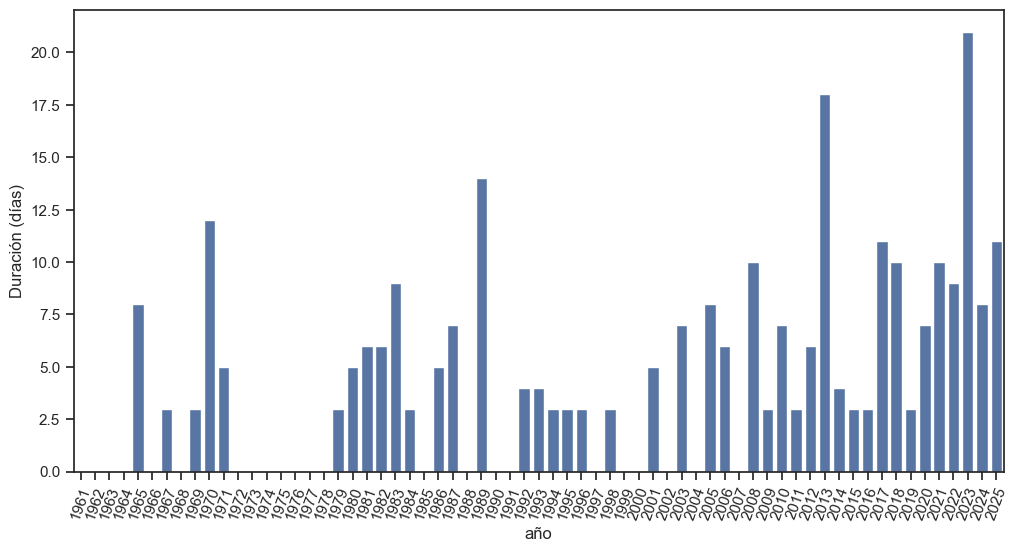

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(12,6))
sns.barplot(data=ola_calor_ext,x="año", y="Duración (días)", estimator="sum", errorbar=None)
plt.xticks(rotation=70)
plt.show()

In [ ]:
years = list(range(1961,2026,1))
ola_calor["año"].isin(years)

0     True
1     True
2     True
3     True
4     True
      ... 
66    True
67    True
68    True
69    True
70    True
Name: año, Length: 71, dtype: bool

## último año

In [31]:
temp = pd.read_csv("..//data//raw//Registro_temperaturas-07082025//registro-temperatura-last-365d.csv",
                           sep=";")
temp

,FECHA,TMAX,TMIN,NOMBRE
0,6/8/2025,14.2,8.3,AEROPARQUE AERO
1,6/8/2025,9.4,4.9,AZUL AERO
2,6/8/2025,15.5,4.6,BAHIA BLANCA AERO
3,6/8/2025,10.9,0.9,BARILOCHE AERO
4,6/8/2025,-14.5,-23.1,BASE BELGRANO II
...,...,...,...,...
42936,7/8/2024,NaN,4.4,VIEDMA AERO
42937,7/8/2024,19.0,7.9,VILLA DE MARIA DEL RIO SECO
42938,7/8/2024,13.3,1.4,VILLA DOLORES AERO
42939,7/8/2024,12.9,8.4,VILLA GESELL AERO


In [33]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42941 entries, 0 to 42940
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   42941 non-null  datetime64[ns]
 1   TMAX    38920 non-null  float64       
 2   TMIN    42315 non-null  float64       
 3   NOMBRE  42941 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 1.3+ MB


In [27]:
pd.to_datetime(temp.FECHA,  format = "%d/%m/%Y")

0       2025-08-06
1       2025-08-06
2       2025-08-06
3       2025-08-06
4       2025-08-06
           ...    
42936   2024-08-07
42937   2024-08-07
42938   2024-08-07
42939   2024-08-07
42940   2024-08-07
Name: FECHA, Length: 42941, dtype: datetime64[ns]

In [32]:
temp["FECHA"] = pd.to_datetime(temp.FECHA,  format = "%d/%m/%Y")
temp


,FECHA,TMAX,TMIN,NOMBRE
0,2025-08-06,14.2,8.3,AEROPARQUE AERO
1,2025-08-06,9.4,4.9,AZUL AERO
2,2025-08-06,15.5,4.6,BAHIA BLANCA AERO
3,2025-08-06,10.9,0.9,BARILOCHE AERO
4,2025-08-06,-14.5,-23.1,BASE BELGRANO II
...,...,...,...,...
42936,2024-08-07,NaN,4.4,VIEDMA AERO
42937,2024-08-07,19.0,7.9,VILLA DE MARIA DEL RIO SECO
42938,2024-08-07,13.3,1.4,VILLA DOLORES AERO
42939,2024-08-07,12.9,8.4,VILLA GESELL AERO


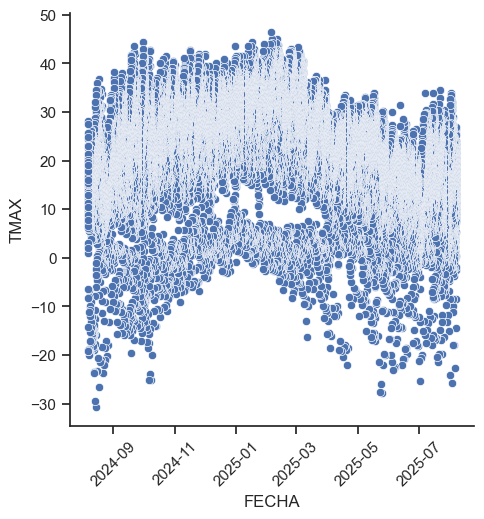

In [34]:
sns.set_theme(style="ticks")
sns.relplot(
    data=temp
    # , kind="line"
    ,x="FECHA", y="TMAX"
    #, col="align"
    # ,hue="bosque_nativo"
    #, size="coherence"
    # , style="bosque_nativo"
    #facet_kws=dict(sharex=False)
    
)
plt.xticks(rotation=45)
plt.show()